# Урок 15.15. Оптимизация: как искать лучшее

**Интерактивная версия:** `lessons/lesson_15_15/web/index.html`

После урока вы сможете:

- ставить задачу оптимизации, различать глобальные и локальные минимумы и видеть, когда минимума нет;
- проверять условия оптимальности, в том числе условия ККТ, и читать множители как теневые цены;
- выбирать методы без производных: случайный поиск, золотое сечение и Брент, Нелдер — Мид, мультистарт,
  отжиг, байесовская оптимизация, последовательное деление;
- подбирать длину шага спуска и оценивать скорость сходимости по обусловленности;
- понимать моментум, Adam, Ньютон и BFGS, стохастический градиент и расписания темпа;
- решать задачи с ограничениями, линейные программы и дискретные задачи;
- видеть бустинг как оптимизацию: направление, длина шага, регуляризация темпом и ранней остановкой.

Разделы идут в том же порядке, что и 36 шагов урока (семь блоков). Числа урока проверяются расчётом
(`assert`), ключевые — сверкой со `scipy.optimize` и scikit-learn. Случайность — через генератор курса
Mulberry32, как в веб-версии: числа совпадают с виджетами.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog, minimize, minimize_scalar
from scipy.stats import norm

from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET

use_course_style()
PHI = (math.sqrt(5) - 1) / 2

## Блок 1. Постановка задачи

### Шаг 1. Задача о загоне

Максимизируем площадь $A(x) = x(40 - 2x)$ при $0 \le x \le 20$ — то же, что минимизируем $-A$.

In [2]:
res = minimize_scalar(lambda t: -t * (40 - 2 * t), bounds=(0, 20), method="bounded")
print(f"x = {res.x:.4f}, площадь {-res.fun:.2f} м²")
assert abs(res.x - 10) < 1e-4 and abs(-res.fun - 200) < 1e-6

x = 10.0000, площадь 200.00 м²


### Шаг 2. Минимумы, плато и задачи без минимума

Критические точки $x^4 - 4x^2 + x$, спуск из $x_0 = 1.9$ — в локальную яму.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


критические точки: [-1.473  0.126  1.347]  значения: [-5.444  0.063 -2.619]
спуск из 1.9 → 1.347


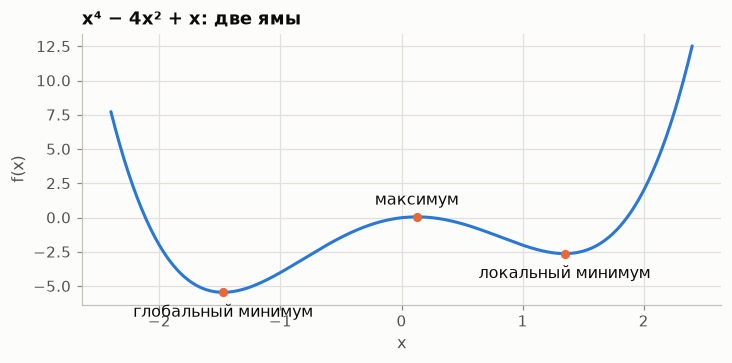

In [3]:
f2 = lambda x: x**4 - 4 * x**2 + x  # noqa: E731
roots = np.sort(np.roots([4, 0, -8, 1]).real)
print("критические точки:", roots.round(3), " значения:", f2(roots).round(3))
x = 1.9
for _ in range(500):
    x -= 0.01 * (4 * x**3 - 8 * x + 1)
print("спуск из 1.9 →", round(x, 3))
assert abs(x - 1.347) < 1e-3

xs = np.linspace(-2.4, 2.4, 400)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(xs, f2(xs), color=BLUE, lw=2)
ax.scatter(roots, f2(roots), color=ORANGE, zorder=3)
for r, lab in zip(roots, ["глобальный минимум", "максимум", "локальный минимум"]):
    ax.annotate(lab, (r, f2(r)), textcoords="offset points", xytext=(0, -16 if lab != "максимум" else 8), ha="center")
ax.set(xlabel="x", ylabel="f(x)", title="x⁴ − 4x² + x: две ямы")
plt.show()

Логистическая регрессия на разделимых данных: минимума нет, вес растёт бесконечно (≈ как логарифм числа шагов).

In [4]:
xs_sep = np.array([-2, -1.2, -0.6, -0.3, 0.4, 0.8, 1.5, 2.2])
s_sep = np.array([-1, -1, -1, -1, 1, 1, 1, 1])


def sep_grad(w, lam=0.0):
    return (-s_sep * xs_sep / (1 + np.exp(s_sep * w * xs_sep))).mean() + lam * w


w = 0.0
for k in range(1, 10001):
    w -= 2 * sep_grad(w)
    if k in (100, 1000, 10000):
        print(f"k = {k:5d}: w = {w:.3f}")
assert abs(w - 18.949) < 1e-3

k =   100: w = 6.474
k =  1000: w = 12.166
k = 10000: w = 18.949


### Шаг 5. Условия оптимальности: минимум на краю отрезка

In [5]:
res = minimize_scalar(lambda t: (t - 1) ** 2 + 0.5, bounds=(1.5, 2.8), method="bounded", options={"xatol": 1e-10})
print(f"минимум на [1.5, 2.8]: x = {res.x:.6f}, f'(x) = {2 * (res.x - 1):.3f} ≥ 0")
assert abs(res.x - 1.5) < 1e-6

минимум на [1.5, 2.8]: x = 1.500000, f'(x) = 1.000 ≥ 0


## Блок 2. Поиск без производных

### Шаги 6–7. Сетка и случайный поиск

Сколько случайных точек нужно, чтобы с вероятностью 95 % попасть в лучшие 5 %? И сетка против случайного поиска
на функции, где важен только $x$.

In [6]:
n59 = math.ceil(math.log(0.05) / math.log(0.95))
print("нужно случайных точек:", n59, "; сетка 5 значений на 4 оси:", 5**4)
assert n59 == 59

score = lambda x, y: math.exp(-(((x - 0.37) / 0.08) ** 2)) * (1 + 0.05 * math.sin(6 * y))  # noqa: E731
for n in (9, 16, 36):
    k = round(math.sqrt(n))
    g = np.linspace(0, 1, k)
    grid_best = max(score(a, b) for a in g for b in g)
    rnd = []
    for r in range(500):
        rr = Mulberry32(5000 + r)
        rnd.append(max(score(rr.random(), rr.random()) for _ in range(n)))
    print(f"n = {n:2d}: сетка {grid_best:.3f}, случайный поиск в среднем {np.mean(rnd):.3f}")
    if n == 9:
        assert abs(grid_best - 0.072) < 1e-3 and abs(np.mean(rnd) - 0.675) < 1e-3

нужно случайных точек: 59 ; сетка 5 значений на 4 оси: 625
n =  9: сетка 0.072, случайный поиск в среднем 0.675
n = 16: сетка 0.847, случайный поиск в среднем 0.816
n = 36: сетка 0.909, случайный поиск в среднем 0.961


### Шаг 8. Сужение отрезка: дихотомия, троичный поиск, золотое сечение

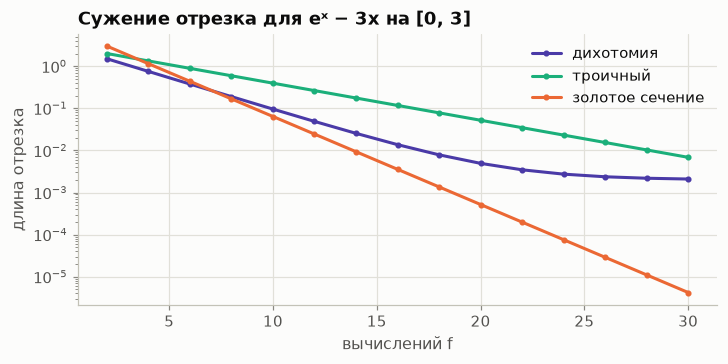

после 30 вычислений: {'дихотомия': '2.1e-03', 'троичный': '6.9e-03', 'золотое сечение': '4.2e-06'}
до длины 0.001: 17 сжатий, 19 вычислений; длина 8.40e-04


In [7]:
def golden(f, a, b, evals):
    c, d = b - PHI * (b - a), a + PHI * (b - a)
    fc, fd = f(c), f(d)
    for _ in range(evals - 2):
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - PHI * (b - a)
            fc = f(c)
        else:
            a, c, fc = c, d, fd
            d = a + PHI * (b - a)
            fd = f(d)
    return a, b


def two_point(f, a, b, evals, method):
    for _ in range(evals // 2):
        if method == "dich":
            m = (a + b) / 2
            x1, x2 = m - 1e-3, m + 1e-3
        else:
            x1, x2 = a + (b - a) / 3, b - (b - a) / 3
        if f(x1) < f(x2):
            b = x2
        else:
            a = x1
    return a, b


fe = lambda x: math.exp(x) - 3 * x  # noqa: E731
E = np.arange(2, 31, 2)
lens = {m: [] for m in ("дихотомия", "троичный", "золотое сечение")}
for e in E:
    lens["дихотомия"].append(np.subtract(*two_point(fe, 0, 3, e, "dich")[::-1]))
    lens["троичный"].append(np.subtract(*two_point(fe, 0, 3, e, "tern")[::-1]))
    lens["золотое сечение"].append(np.subtract(*golden(fe, 0, 3, e)[::-1]))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for (m, v), c in zip(lens.items(), [VIOLET, AQUA, ORANGE]):
    ax.semilogy(E, v, "o-", color=c, label=m, ms=3)
ax.set(xlabel="вычислений f", ylabel="длина отрезка", title="Сужение отрезка для eˣ − 3x на [0, 3]")
ax.legend()
plt.show()
print("после 30 вычислений:", {m: f"{v[-1]:.1e}" for m, v in lens.items()})
k_need = math.ceil(math.log(1 / 3000) / math.log(PHI))
a, b = golden(fe, 0, 3, k_need + 2)
print(f"до длины 0.001: {k_need} сжатий, {k_need + 2} вычислений; длина {b - a:.2e}")
assert b - a < 1e-3 and k_need == 17

### Шаг 9. Параболическая интерполяция и метод Брента

In [8]:
pts = [(x, fe(x)) for x in (0, 1.5, 3)]
for k in range(1, 9):
    (x0, y0), (x1, y1), (x2, y2) = pts[-3:]
    d01, d12 = (y1 - y0) / (x1 - x0), (y2 - y1) / (x2 - x1)
    A = (d12 - d01) / (x2 - x0)
    v = (x0 + x1) / 2 - d01 / (2 * A)
    pts.append((v, fe(v)))
    print(f"шаг {k}: x = {v:.12f}, ошибка {abs(v - math.log(3)):.1e}")
assert abs(pts[-1][0] - math.log(3)) < 1e-9
res = minimize_scalar(fe, bracket=(0, 1.5))
print("метод Брента:", res.x, "за", res.nfev, "вычислений")

шаг 1: x = 0.876006136522, ошибка 2.2e-01
шаг 2: x = 1.137821303257, ошибка 3.9e-02
шаг 3: x = 1.049461947205, ошибка 4.9e-02
шаг 4: x = 1.098642418199, ошибка 3.0e-05
шаг 5: x = 1.098290807259, ошибка 3.2e-04
шаг 6: x = 1.098614683503, ошибка 2.4e-06
шаг 7: x = 1.098612286939, ошибка 1.7e-09
шаг 8: x = 1.098612288534, ошибка 1.3e-10
метод Брента: 1.0986122813141193 за 13 вычислений


### Шаг 10. Нелдер — Мид (scipy с тем же начальным симплексом, что на странице)

In [9]:
banana = lambda p: (1 - p[0]) ** 2 + 5 * (p[1] - p[0] ** 2) ** 2  # noqa: E731
banana_grad = lambda p: np.array([-2 * (1 - p[0]) - 20 * p[0] * (p[1] - p[0] ** 2), 10 * (p[1] - p[0] ** 2)])  # noqa: E731
sim0 = np.array([[-1.2, 1.5], [-0.95, 1.5], [-1.2, 1.75]])
res = minimize(banana, sim0[0], method="Nelder-Mead", options={"initial_simplex": sim0, "xatol": 1e-4, "fatol": 1e-4})
print("Нелдер — Мид:", res.x.round(4), "вычислений f:", res.nfev)
assert res.nfev == 99

Нелдер — Мид: [1. 1.] вычислений f: 99


### Шаги 11–12. Мультистарт и имитация отжига

In [10]:
fm = lambda x: 0.02 * x * x - 0.8 * np.cos(3 * x) - 1.4 * np.exp(-((x - 2.1) ** 2) / 0.08)  # noqa: E731
dfm = lambda x: 0.04 * x + 2.4 * np.sin(3 * x) + 35 * (x - 2.1) * np.exp(-((x - 2.1) ** 2) / 0.08)  # noqa: E731
grid = np.linspace(-6, 6, 24001)
x_glob = grid[fm(grid).argmin()]


def local_descent(x):
    for _ in range(1500):
        x = np.clip(x - 0.02 * dfm(x), -6, 6)
    return x


ends = local_descent(np.linspace(-6, 6, 601))  # векторно: 601 старт сразу
w_share = np.mean(np.abs(ends - x_glob) < 0.05)
print(f"глобальный минимум {x_glob:.3f}; доля области притяжения w = {w_share:.3f}")
for n in (3, 10, 20):
    print(f"  {n} стартов: P = 1 − (1 − w)^n = {1 - (1 - w_share) ** n:.3f}")
assert abs(w_share - 0.175) < 0.002


def anneal(seed, T0, K):
    r = Mulberry32(seed)
    x = -6 + 12 * r.random()
    fx = fm(x)
    a = (0.01 / T0) ** (1 / K) if T0 > 0 else 0
    T = T0
    for _ in range(K):
        c = min(6, max(-6, x + 0.5 * r.normal()))
        fc = fm(c)
        u = r.random()
        if fc < fx or (T > 0 and u < math.exp(-(fc - fx) / T)):
            x, fx = c, fc
        T *= a
    return x


ok = np.mean([abs(anneal(1000 + r, 1.0, 3000) - x_glob) < 0.15 for r in range(300)])
ok0 = np.mean([abs(anneal(1000 + r, 0.0, 3000) - x_glob) < 0.15 for r in range(300)])
print(f"отжиг T0 = 1, 3000 шагов: успех {ok:.0%};  T0 = 0: {ok0:.0%}")
assert abs(ok - 0.76) < 0.01 and abs(ok0 - 0.40) < 0.01

глобальный минимум 2.097; доля области притяжения w = 0.175
  3 стартов: P = 1 − (1 − w)^n = 0.438
  10 стартов: P = 1 − (1 − w)^n = 0.853
  20 стартов: P = 1 − (1 − w)^n = 0.979


отжиг T0 = 1, 3000 шагов: успех 76%;  T0 = 0: 40%


### Шаг 13. Байесовская оптимизация: гауссовский процесс и ожидаемое улучшение

Ядро RBF с фиксированной длиной $\ell = 0.06$, нормировка $y$ как в `sklearn` (`normalize_y=True`).

точки: [0.1   0.5   0.9   0.055 0.16  0.22  0.295 0.695 0.735 0.66  0.68  0.39
 1.    0.    0.83 ]
лучшее найденное 0.22717, оптимум 0.22716, отставание 1.0e-05


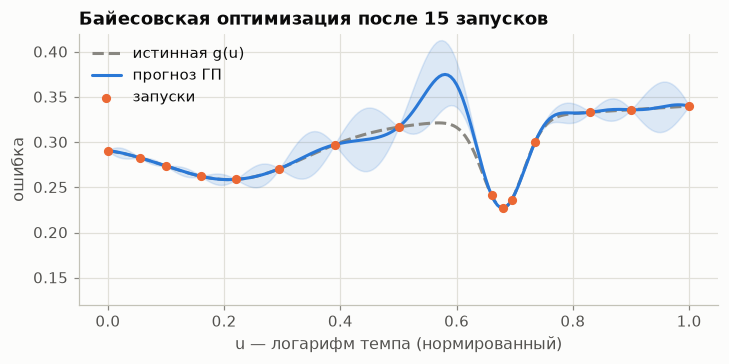

случайный поиск, 15 точек: среднее отставание 0.0189


In [11]:
g_bo = lambda u: 0.3 - 0.1 * np.exp(-((u - 0.68) ** 2) / (2 * 0.035**2)) - 0.05 * np.exp(-((u - 0.22) ** 2) / (2 * 0.12**2)) + 0.04 * u  # noqa: E731
ugrid = np.linspace(0, 1, 201)
g_star = g_bo(np.linspace(0, 1, 100001)).min()


def gp_posterior(X, Y, ell, noise=1e-6):
    X, Y = np.asarray(X), np.asarray(Y)
    m, s = Y.mean(), Y.std()
    yn = (Y - m) / s
    k = lambda a, b: np.exp(-((a[:, None] - b[None, :]) ** 2) / (2 * ell**2))  # noqa: E731
    K = k(X, X) + noise * np.eye(len(X))
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, yn))
    Ks = k(X, ugrid)
    mu = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    sd = np.sqrt(np.maximum(1 - (v**2).sum(0), 0))
    return mu, sd, m, s


X, Y = [0.1, 0.5, 0.9], [g_bo(0.1), g_bo(0.5), g_bo(0.9)]
for _ in range(12):
    mu, sd, m, s = gp_posterior(X, Y, 0.06)
    imp = (min(Y) - m) / s - mu - 0.01
    z = np.divide(imp, sd, out=np.zeros_like(imp), where=sd > 1e-12)
    ei = np.where(sd > 1e-12, imp * norm.cdf(z) + sd * norm.pdf(z), 0)
    u = ugrid[ei.argmax()]
    X.append(u)
    Y.append(g_bo(u))
print("точки:", np.round(X, 3))
print(f"лучшее найденное {min(Y):.5f}, оптимум {g_star:.5f}, отставание {min(Y) - g_star:.1e}")
assert min(Y) - g_star < 1e-3

# сверка апостериорного среднего с sklearn
from sklearn.gaussian_process import GaussianProcessRegressor  # noqa: E402
from sklearn.gaussian_process.kernels import RBF  # noqa: E402

gp = GaussianProcessRegressor(RBF(0.06, length_scale_bounds="fixed"), alpha=1e-6, normalize_y=True, optimizer=None)
gp.fit(np.array(X)[:, None], Y)
mu, sd, m, s = gp_posterior(X, Y, 0.06)
assert np.allclose(gp.predict(ugrid[:, None]), m + s * mu, atol=1e-6)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ugrid, g_bo(ugrid), "--", color=MUTED, label="истинная g(u)")
ax.plot(ugrid, m + s * mu, color=BLUE, label="прогноз ГП")
ax.fill_between(ugrid, m + s * (mu - 2 * sd), m + s * (mu + 2 * sd), color=BLUE, alpha=0.15)
ax.scatter(X, Y, color=ORANGE, zorder=3, label="запуски")
ax.set(xlabel="u — логарифм темпа (нормированный)", ylabel="ошибка", title="Байесовская оптимизация после 15 запусков", ylim=(0.12, 0.42))
ax.legend()
plt.show()

rnd_reg = []
for r in range(2000):
    rr = Mulberry32(7000 + r)
    rnd_reg.append(min(g_bo(rr.random()) for _ in range(15)) - g_star)
print(f"случайный поиск, 15 точек: среднее отставание {np.mean(rnd_reg):.4f}")

### Шаг 14. Последовательное деление

In [12]:
def halving(seed, noise, r0=1):
    r = Mulberry32(seed)
    cf = [(0.2 + 0.15 * r.random(), 0.15 + 0.45 * r.random(), 0.05 + 0.6 * r.random()) for _ in range(27)]
    at = lambda i, t: cf[i][0] + cf[i][1] / (1 + cf[i][2] * t)  # noqa: E731
    rn = Mulberry32(seed + 777)
    rungs = [1, 3, 9, 27] if r0 == 1 else [3, 9, 27]
    alive, cost = list(range(27)), 0
    for k, t in enumerate(rungs):
        obs = sorted(((i, at(i, t) + noise * rn.normal()) for i in alive), key=lambda p: p[1])
        cost += len(alive) * t
        keep = 1 if k == len(rungs) - 1 else max(1, round(len(alive) / 3))
        alive = [i for i, _ in obs[:keep]]
    truth = [at(i, 27) for i in range(27)]
    return alive[0] == int(np.argmin(truth)), cost


for noise in (0, 0.01, 0.04):
    res_h = [halving(2000 + r, noise) for r in range(500)]
    print(f"шум {noise}: затраты {res_h[0][1]} эпох из 729, лучший дожил в {np.mean([q[0] for q in res_h]):.0%}")

шум 0: затраты 108 эпох из 729, лучший дожил в 66%
шум 0.01: затраты 108 эпох из 729, лучший дожил в 60%
шум 0.04: затраты 108 эпох из 729, лучший дожил в 38%


## Блок 3. Градиентный спуск всерьёз

### Шаги 15–16. Режимы шага и скорость сходимости

In [13]:
for eta in (0.2, 0.25, 0.4, 0.5, 0.6):
    print(f"η = {eta}: множитель 1 − 4η = {1 - 4 * eta:+.2f}")
kappa = 10
p, k = np.array([1.0, 1.0]), 0
while 0.5 * (p[0] ** 2 + kappa * p[1] ** 2) >= 1e-8:
    p = p - 2 / (kappa + 1) * np.array([p[0], kappa * p[1]])
    k += 1
print("κ = 10: шагов до 1e-8 —", k)
assert k == 51

η = 0.2: множитель 1 − 4η = +0.20
η = 0.25: множитель 1 − 4η = +0.00
η = 0.4: множитель 1 − 4η = -0.60
η = 0.5: множитель 1 − 4η = -1.00
η = 0.6: множитель 1 − 4η = -1.40
κ = 10: шагов до 1e-8 — 51


### Шаги 17–18. Поиск вдоль прямой: точный шаг и правило Армихо

In [14]:
def bowl_run(kappa, p0, mode):
    A = np.diag([1.0, kappa])
    p = np.array(p0, float)
    for k in range(1, 5000):
        g = A @ p
        t = g @ g / (g @ A @ g) if mode == "exact" else (2 / (kappa + 1) if mode == "best" else 1 / kappa)
        p = p - t * g
        if 0.5 * p @ A @ p < 1e-6:
            return k


print("старт (−4, 1.2):", [bowl_run(25, (-4, 1.2), m) for m in ("exact", "best", "safe")])
print("худший старт:  ", [bowl_run(25, (-4, 4 / 25), m) for m in ("exact", "best", "safe")])
assert [bowl_run(25, (-4, 1.2), m) for m in ("exact", "best", "safe")] == [14, 107, 195]

bowl = lambda p: 0.5 * (p[0] ** 2 + 25 * p[1] ** 2)  # noqa: E731
bowl_grad = lambda p: np.array([p[0], 25 * p[1]])  # noqa: E731


def armijo(p, c=0.3, rho=0.5):
    g, t, tries = bowl_grad(p), 1.0, 1
    while bowl(p - t * g) > bowl(p) - c * t * (g @ g) and t > 1e-8:
        t *= rho
        tries += 1
    return t, tries


p, it, calls = np.array([-3.0, 1.2]), 0, 0
while bowl(p) >= 1e-6:
    t, tries = armijo(p)
    calls += tries + 1
    p = p - t * bowl_grad(p)
    it += 1
print("Армихо: итераций", it, "вычислений f", calls)
assert (it, calls) == (87, 492)

старт (−4, 1.2): [14, 107, 195]
худший старт:   [100, 100, 195]
Армихо: итераций 87 вычислений f 492


### Шаги 19–20. Покоординатный спуск и проксимальный шаг

In [15]:
for rho in (0.8, 0.99):
    w = np.array([2.5, 2.2])
    f_cd = lambda w, rho=rho: 0.5 * (w[0] ** 2 + 2 * rho * w[0] * w[1] + w[1] ** 2)  # noqa: E731
    for k in range(1, 5001):
        j = (k - 1) % 2
        w[j] = -rho * w[1 - j]
        if f_cd(w) < 1e-8:
            break
    print(f"ρ = {rho}: покоординатный спуск — {k} обновлений")

soft = lambda z, t: np.sign(z) * np.maximum(np.abs(z) - t, 0)  # noqa: E731
gsmooth = lambda w: np.array([2 * (w[0] - 2), 8 * (w[1] - 1.5)])  # noqa: E731
lam = 6.0
p = q = np.array([-1.0, -0.5])
for k in range(1, 61):
    p = soft(p - gsmooth(p) / 8, lam / 8)
    q = q - 0.12 / np.sqrt(k) * (gsmooth(q) + lam * np.sign(q))
print("ISTA:", p, " субградиент:", q.round(4))
assert p[0] == 0 and q[0] != 0

# сверка мягкого порога с Lasso из scikit-learn: одномерная задача ½(w − z)² + τ|w|
from sklearn.linear_model import Lasso  # noqa: E402

z, tau = 1.3, 0.5
Xz = np.ones((1, 1))
lz = Lasso(alpha=tau, fit_intercept=False).fit(Xz, [z])  # цель ½(z − w)² + τ|w| при n = 1
assert abs(lz.coef_[0] - soft(z, tau)) < 1e-12

ρ = 0.8: покоординатный спуск — 42 обновлений
ρ = 0.99: покоординатный спуск — 767 обновлений
ISTA: [0.   0.75]  субградиент: [0.0119 0.75  ]


## Блок 4. Ускорение и второй порядок

### Шаг 21. Моментум: √κ вместо κ

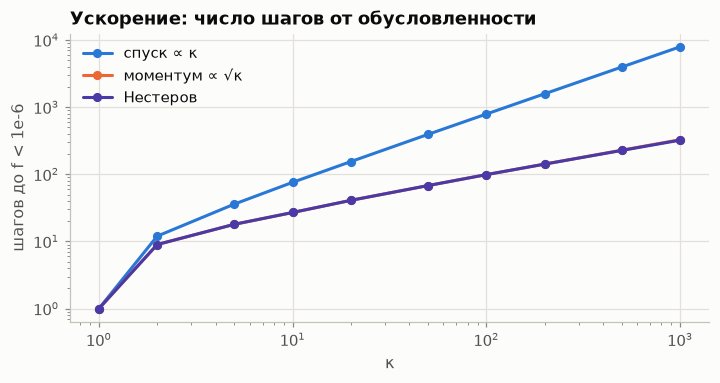

κ = 1000: спуск 7944  моментум 328
наклон для моментума: 0.54 (≈ 0.5)


In [16]:
def bowl_steps(kappa, method, beta, tol=1e-6):
    p, v, eta = np.array([-4.0, 1.5]), np.zeros(2), 1 / kappa
    for k in range(1, 300001):
        q = p + beta * v if method == "nest" else p
        g = np.array([q[0], kappa * q[1]])
        if method == "gd":
            p = p - eta * g
        else:
            v = beta * v - eta * g
            p = p + v
        if 0.5 * (p[0] ** 2 + kappa * p[1] ** 2) < tol:
            return k


KS = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
gd_s = [bowl_steps(k, "gd", 0) for k in KS]
hb_s = [bowl_steps(k, "mom", (1 - 1 / math.sqrt(k)) ** 2) for k in KS]
ne_s = [bowl_steps(k, "nest", (math.sqrt(k) - 1) / (math.sqrt(k) + 1)) for k in KS]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.loglog(KS, gd_s, "o-", color=BLUE, label="спуск ∝ κ")
ax.loglog(KS, hb_s, "o-", color=ORANGE, label="моментум ∝ √κ")
ax.loglog(KS, ne_s, "o-", color=VIOLET, label="Нестеров")
ax.set(xlabel="κ", ylabel="шагов до f < 1e-6", title="Ускорение: число шагов от обусловленности")
ax.legend()
plt.show()
print("κ = 1000: спуск", gd_s[-1], " моментум", hb_s[-1])
assert (gd_s[-1], hb_s[-1]) == (7944, 328)
slope = np.polyfit(np.log(KS[3:]), np.log(hb_s[3:]), 1)[0]
print(f"наклон для моментума: {slope:.2f} (≈ 0.5)")

### Шаг 22. Adam и поворот осей

In [17]:
def adam_steps(A, p0=(-4, 1.5), lr=0.1, tol=1e-4, steps=3000):
    p, m, s = np.array(p0, float), np.zeros(2), np.zeros(2)
    for k in range(1, steps + 1):
        g = A @ p
        m = 0.9 * m + 0.1 * g
        s = 0.999 * s + 0.001 * g**2
        p = p - lr * (m / (1 - 0.9**k)) / (np.sqrt(s / (1 - 0.999**k)) + 1e-8)
        if 0.5 * p @ A @ p < tol:
            return k


for deg in (0, 45):
    th = np.deg2rad(deg)
    Rm = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
    A = Rm.T @ np.diag([1.0, 25.0]) @ Rm
    print(f"поворот {deg:2d}°: Adam — {adam_steps(A)} шагов")
assert adam_steps(np.diag([1.0, 25.0])) == 105

поворот  0°: Adam — 105 шагов
поворот 45°: Adam — 564 шагов


### Шаг 24. Ньютон и BFGS (scipy использует поиск шага по Вольфе — числа чуть другие, чем на странице)

In [18]:
hess = lambda p: np.array([[2 - 20 * p[1] + 60 * p[0] ** 2, -20 * p[0]], [-20 * p[0], 10]])  # noqa: E731
for method in ("BFGS", "Newton-CG", "CG"):
    kw = {"hess": hess} if method == "Newton-CG" else {}
    res = minimize(banana, [-1.2, 1.5], jac=banana_grad, method=method, tol=1e-12, **kw)
    print(f"{method:9}: итераций {res.nit:3d}, вычислений f {res.nfev:3d}, x = {res.x.round(6)}")

BFGS     : итераций  19, вычислений f  26, x = [1. 1.]
Newton-CG: итераций  15, вычислений f  18, x = [1. 1.]
CG       : итераций  28, вычислений f  72, x = [1. 1.]


## Блок 5. Стохастическая оптимизация

### Шаг 25. Градиент по мини-батчу: несмещённость и разброс $\sigma/\sqrt B$

In [19]:
r = Mulberry32(3)
N = 200
xs_l = np.array([r.uniform(-1, 1) for _ in range(N)])
ys_l = np.array([1 + 2 * x + r.normal(0, 0.5) for x in xs_l])
loss_l = lambda b, k: ((ys_l - b - k * xs_l) ** 2).mean() / 2  # noqa: E731
k_opt, b_opt = np.polyfit(xs_l, ys_l, 1)
L_min = loss_l(b_opt, k_opt)

gb = -ys_l
rr = Mulberry32(910)
est = np.array([gb[rr.sample(N, 10)].mean() for _ in range(300)])
theory = gb.std() / np.sqrt(10) * np.sqrt((N - 10) / (N - 1))
print(f"B = 10: разброс опыт {est.std():.3f}, теория {theory:.3f}")
assert abs(est.std() - 0.366) < 1e-3

B = 10: разброс опыт 0.366, теория 0.367


### Шаг 26. Пол шума ∝ η/B и расписания темпа

In [20]:
def floor(B, eta):
    acc = []
    for seed in range(3):
        rg = Mulberry32(300 + seed)
        b = k = 0.0
        for t in range(1, 4001):
            idx = [rg.randint(N) for _ in range(B)]
            res_ = ys_l[idx] - b - k * xs_l[idx]
            b += eta * res_.mean()
            k += eta * (res_ * xs_l[idx]).mean()
            if t > 2000:
                acc.append(loss_l(b, k) - L_min)
    return np.mean(acc)


etas = [0.01, 0.02, 0.05, 0.1]
fl1 = [floor(1, e) for e in etas]
fl10 = floor(10, 0.05)
slope = np.polyfit(np.log(etas), np.log(fl1), 1)[0]
print(f"наклон «пол — темп»: {slope:.2f}; B = 1 против B = 10 при η = 0.05: ×{fl1[2] / fl10:.1f}")
assert 0.8 < slope < 1.25


def sgd(B, lr, epochs, sched, seed):
    rg = Mulberry32(seed)
    b = k = 0.0
    t, T = 0, epochs * int(np.ceil(N / B))
    for _ in range(epochs):
        perm = rg.permutation(N)
        for s0 in range(0, N, B):
            idx = perm[s0:s0 + B]
            res_ = ys_l[idx] - b - k * xs_l[idx]
            eta = lr if sched == "const" else (lr / (1 + t / 100) if sched == "decay" else lr * (1 + np.cos(np.pi * t / T)) / 2)
            b += eta * res_.mean()
            k += eta * (res_ * xs_l[idx]).mean()
            t += 1
    return loss_l(b, k) - L_min


for sched, lr in (("const", 0.1), ("const", 0.01), ("decay", 0.1), ("cos", 0.1)):
    print(f"расписание {sched:5} {lr}: превышение потерь {sgd(1, lr, 20, sched, 300):.1e}")

наклон «пол — темп»: 1.03; B = 1 против B = 10 при η = 0.05: ×11.2
расписание const 0.1: превышение потерь 7.2e-03
расписание const 0.01: превышение потерь 3.9e-06
расписание decay 0.1: превышение потерь 3.9e-06
расписание cos   0.1: превышение потерь 9.2e-08


### Шаг 27. Острые и плоские минимумы

In [21]:
f_sf = lambda x: np.minimum(25 * (x + 2) ** 2 - 1, 0.5 * (x - 1.5) ** 2 - 0.8)  # noqa: E731
d_sf = lambda x: 50 * (x + 2) if 25 * (x + 2) ** 2 - 1 < 0.5 * (x - 1.5) ** 2 - 0.8 else x - 1.5  # noqa: E731


def sf_run(eta, sig, seed):
    rg = Mulberry32(seed)
    x = -4 + 8 * rg.random()
    for _ in range(1500):
        x = min(4, max(-4, x - eta * (d_sf(x) + sig * rg.normal())))
    return x


for eta, sig in ((0.02, 0), (0.041, 0), (0.02, 10)):
    e = np.array([sf_run(eta, sig, 50 + i) for i in range(400)])
    print(f"η = {eta}, σ = {sig}: в острой яме {np.mean(np.abs(e + 2) < 0.35):.0%}")

η = 0.02, σ = 0: в острой яме 33%


η = 0.041, σ = 0: в острой яме 0%


η = 0.02, σ = 10: в острой яме 2%


## Блок 6. Ограничения и дискретные задачи

### Шаг 28. Условия ККТ: проекция на многоугольник и теневая цена

In [22]:
t_kkt = np.array([3.6, 2.4])


def proj(bb):
    cons = [{"type": "ineq", "fun": lambda w: w[0]}, {"type": "ineq", "fun": lambda w: w[1]},
            {"type": "ineq", "fun": lambda w: bb - w[0] - 2 * w[1]}, {"type": "ineq", "fun": lambda w: 3 - w[0]}]
    return minimize(lambda w: 0.5 * ((w - t_kkt) ** 2).sum(), np.zeros(2), constraints=cons, method="SLSQP", tol=1e-12)


res = proj(4)
mu = (t_kkt - res.x) / np.array([1, 2])
print("решение:", res.x.round(4), " t − w* / нормаль:", mu.round(4))
shadow = (proj(4 - 1e-3).fun - proj(4 + 1e-3).fun) / 2e-3
print(f"теневая цена бюджета: μ = {mu[0]:.3f}, численно {shadow:.3f}")
assert np.allclose(res.x, [2.72, 0.64], atol=1e-6) and abs(shadow - 0.88) < 1e-3

решение: [2.72 0.64]  t − w* / нормаль: [0.88 0.88]
теневая цена бюджета: μ = 0.880, численно 0.880


### Шаги 29–30. Штраф, барьер, проекция; L1 и L2

In [23]:
for m_ in (10, 1000):
    print(f"штраф μ = {m_}: x = {(3 + m_) / (1 + m_):.5f}")
for t_ in (1, 0.001):
    print(f"барьер t = {t_}: x = {2 - math.sqrt(1 + t_ / 2):.5f}")
for lam in (0, 2, 4, 12):
    print(f"λ = {lam:2d}: L2 → {np.round([2 / (1 + lam), 6 / (4 + lam)], 3)}, L1 → {[max(0, 2 - lam / 2), max(0, 1.5 - lam / 8)]}")

штраф μ = 10: x = 1.18182
штраф μ = 1000: x = 1.00200
барьер t = 1: x = 0.77526
барьер t = 0.001: x = 0.99975
λ =  0: L2 → [2.  1.5], L1 → [2.0, 1.5]
λ =  2: L2 → [0.667 1.   ], L1 → [1.0, 1.25]
λ =  4: L2 → [0.4  0.75], L1 → [0, 1.0]
λ = 12: L2 → [0.154 0.375], L1 → [0, 0]


### Шаг 31. Линейное программирование и двойственные цены

In [24]:
A_lp = np.array([[1, 1], [1, 3], [1, 0]])
b_lp = np.array([4, 9, 3])
res = linprog(-np.array([3, 2]), A_ub=A_lp, b_ub=b_lp, bounds=[(0, None)] * 2, method="highs")
duals = -res.ineqlin.marginals
print("план:", res.x, " прибыль:", -res.fun, " теневые цены:", duals)
assert np.allclose(res.x, [3, 1]) and np.allclose(duals, [2, 0, 1])
assert abs(duals @ b_lp - (-res.fun)) < 1e-9  # сильная двойственность

план: [3. 1.]  прибыль: 11.0  теневые цены: [2. 0. 1.]


### Шаг 32. Рюкзак: жадность против динамического программирования

In [25]:
w_k = [5, 7, 4, 6, 9, 5, 1, 6, 9, 9]
v_k = [6, 12, 7, 9, 15, 8, 2, 11, 8, 16]


def knap_dp(C):
    best = [0.0] * (C + 1)
    for wi, vi in zip(w_k, v_k):
        for c in range(C, wi - 1, -1):
            best[c] = max(best[c], best[c - wi] + vi)
    return best[C]


def knap_greedy(C):
    left, val = C, 0
    for i in sorted(range(10), key=lambda i: (-v_k[i] / w_k[i], i)):
        if w_k[i] <= left:
            left -= w_k[i]
            val += v_k[i]
    return val


brute = max(sum(v_k[i] for i in S) for r_ in range(11) for S in combinations(range(10), r_) if sum(w_k[i] for i in S) <= 10)
print("C = 10: ДП", knap_dp(10), " перебор", brute, " жадно", knap_greedy(10))
fails = sum(knap_greedy(C) < knap_dp(C) for C in range(1, 41))
print("жадность ошибается при", fails, "вместимостях из 40")
assert (knap_dp(10), brute, knap_greedy(10), fails) == (18, 18, 13, 28)

C = 10: ДП 18.0  перебор 18  жадно 13
жадность ошибается при 28 вместимостях из 40


## Блок 7. Оптимизация внутри бустинга

### Шаг 33. Шаг бустинга: градиент, поиск вдоль прямой, Ньютон, точный минимум в листьях

In [26]:
from sklearn.ensemble import GradientBoostingClassifier  # noqa: E402

r = Mulberry32(11)
n_b = 40
x_b = (np.arange(n_b) + 0.5) / n_b
y_b = np.array([int(r.random() < 1 / (1 + np.exp(-1.5 * np.sin(2 * np.pi * t)))) for t in x_b])
F0 = np.log(y_b.mean() / (1 - y_b.mean()))
p0 = 1 / (1 + np.exp(-F0))
loss_b = lambda F: np.mean(np.logaddexp(0, -F) * y_b + np.logaddexp(0, F) * (1 - y_b))  # noqa: E731
res_b = y_b - p0
kk = min(range(1, n_b), key=lambda k: ((res_b[:k] - res_b[:k].mean()) ** 2).sum() + ((res_b[k:] - res_b[k:].mean()) ** 2).sum())
leaf = (np.arange(n_b) >= kk).astype(int)
h = np.where(leaf == 0, res_b[:kk].mean(), res_b[kk:].mean())
rho = minimize_scalar(lambda t: loss_b(F0 + t * h), bounds=(0, 20), method="bounded", options={"xatol": 1e-10}).x
newton = np.array([res_b[leaf == j].sum() / ((leaf == j).sum() * p0 * (1 - p0)) for j in (0, 1)])
exact = np.array([np.log(y_b[leaf == j].mean() / (1 - y_b[leaf == j].mean())) - F0 for j in (0, 1)])
print(f"потери: F0 {loss_b(np.full(n_b, F0)):.4f}, градиент {loss_b(F0 + h):.4f}, ρ* = {rho:.3f} → {loss_b(F0 + rho * h):.4f}, "
      f"Ньютон {loss_b(F0 + newton[leaf]):.4f}, точно {loss_b(F0 + exact[leaf]):.4f}")
gb = GradientBoostingClassifier(n_estimators=1, learning_rate=1.0, max_depth=1).fit(x_b[:, None], y_b)
assert np.allclose(gb.decision_function(x_b[:, None]), F0 + newton[leaf], atol=1e-10)
print("scikit-learn считает листья шагом Ньютона — совпадение до 1e-10")

потери: F0 0.6881, градиент 0.5807, ρ* = 4.996 → 0.4152, Ньютон 0.4229, точно 0.4127
scikit-learn считает листья шагом Ньютона — совпадение до 1e-10


### Шаг 34. Поэтапный бустинг и путь Lasso

поэтапный бустинг: 701 шагов, веса [ 3.5   0.22 -1.87  0.    1.42]; макс. расхождение с Lasso 0.016


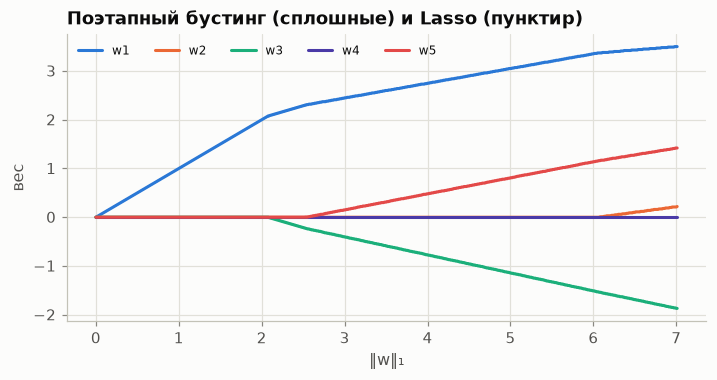

In [27]:
from sklearn.linear_model import lasso_path  # noqa: E402

r = Mulberry32(21)
Z = np.array([[r.normal() for _ in range(5)] for _ in range(60)])
Xs = np.column_stack([Z[:, 0], 0.6 * Z[:, 0] + 0.8 * Z[:, 1], Z[:, 2], 0.5 * Z[:, 2] + 0.5 * Z[:, 3] + 0.7 * Z[:, 1], Z[:, 4]])
Xs = (Xs - Xs.mean(0)) / Xs.std(0)
ys = np.array([3 * a - 2 * c + 1.5 * e + 0.5 * b + r.normal(0, 1.5) for a, b, c, d, e in Xs])
ys = ys - ys.mean()

eps = 0.01
w_sw, res_sw, path = np.zeros(5), ys.copy(), [np.zeros(5)]
while True:
    c = Xs.T @ res_sw / 60
    j = np.argmax(np.abs(c))
    if abs(c[j]) < eps / 2:
        break
    w_sw[j] += eps * np.sign(c[j])
    res_sw -= eps * np.sign(c[j]) * Xs[:, j]
    path.append(w_sw.copy())
path = np.array(path)
alphas, coefs, _ = lasso_path(Xs, ys, alphas=np.geomspace(1, 1e-3, 120) * np.abs(Xs.T @ ys).max() / 60)
l1_las = np.abs(coefs).sum(0)
l1_sw = np.abs(path).sum(1)
diff = max(np.abs(np.interp(l1_sw[i], l1_las, coefs[j]) - path[i, j]) for i in range(len(path)) for j in range(5))
print(f"поэтапный бустинг: {len(path) - 1} шагов, веса {w_sw.round(2)}; макс. расхождение с Lasso {diff:.3f}")
assert diff < 0.03

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for j, col in enumerate([BLUE, ORANGE, AQUA, VIOLET, RED]):
    ax.plot(l1_sw, path[:, j], color=col, lw=2, label=f"w{j + 1}")
    ax.plot(l1_las, coefs[j], "--", color=col, lw=1.2)
ax.set(xlabel="‖w‖₁", ylabel="вес", title="Поэтапный бустинг (сплошные) и Lasso (пунктир)")
ax.legend(ncols=5, fontsize=8)
plt.show()

### Шаг 35. Ранняя остановка ≈ гребневая регрессия

In [28]:
r = Mulberry32(8)
Xe = []
for _ in range(30):
    a = r.normal()
    Xe.append([a, 0.85 * a + 0.53 * r.normal()])
Xe = np.array(Xe)
ye = np.array([1.5 * a + 0.5 * b + r.normal(0, 0.8) for a, b in Xe])
A_e, c_e = Xe.T @ Xe / 30, Xe.T @ ye / 30
eta = 1 / np.linalg.eigvalsh(A_e).max()
w_e = np.zeros(2)
for k in range(1, 201):
    w_e -= eta * (A_e @ w_e - c_e)
    if k in (20, 200):
        ridge = np.linalg.solve(A_e + np.eye(2) / (eta * k), c_e)
        print(f"k = {k:3d}: спуск {w_e.round(3)}, гребневая (λ = {1 / (eta * k):.4f}) {ridge.round(3)}, расстояние {np.linalg.norm(w_e - ridge):.3f}")
print("собственные числа XᵀX/n:", np.linalg.eigvalsh(A_e).round(3))

k =  20: спуск [1.192 0.839], гребневая (λ = 0.0977) [1.109 0.826], расстояние 0.084
k = 200: спуск [1.282 0.744], гребневая (λ = 0.0098) [1.254 0.763], расстояние 0.034
собственные числа XᵀX/n: [0.094 1.953]


## Упражнения

Задания — в `exercises/tasks.md`, решения — в `exercises/solutions.py`. Попробуйте сначала сами:

1. Сколько вычислений нужно золотому сечению на $[0, 3]$ до точности 0.001?
2. Найдите лучшее $\beta$ моментума для $\kappa = 100$ перебором и сравните с $(1 - 1/\sqrt\kappa)^2$.
3. Реализуйте BFGS и сравните с `scipy.optimize.minimize(method="BFGS")`.
4. Решите ЛП из шага 31 при изменённых ценах и проверьте сильную двойственность.
5. Сравните значения листа: Ньютон, точный минимум и Ньютон с $\lambda = 1$.